In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

##Load data

In [7]:
# Preprocess data
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names

#overview of the data
df = pd.DataFrame(wine.data, columns=wine.feature_names)
print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [8]:
# Apply scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Apply Clustering (Before PCA)

###Elbow method to choose k

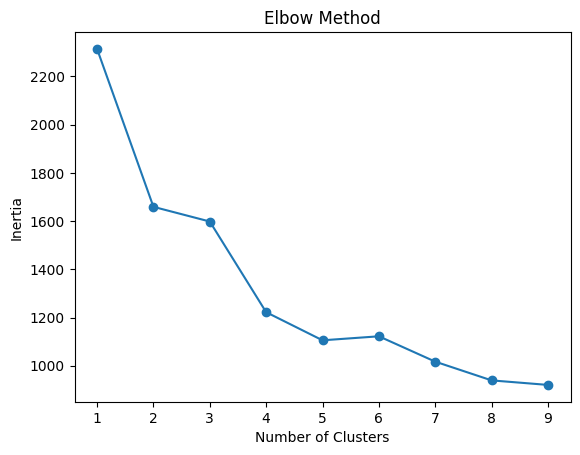

In [9]:
inertia = []

for k in range(1,10):

    model = KMeans(n_clusters=k)
    model.fit(X_scaled)

    inertia.append(model.inertia_)
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

##K-mean clustring before and after PCA

In [10]:
# We use 4 clusters
kmeans_before = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_before = kmeans_before.fit_predict(X_scaled)
score_before = silhouette_score(X_scaled, labels_before)

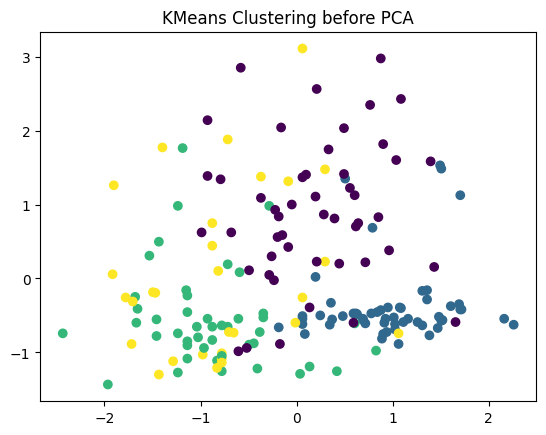

In [12]:
#vizualize clusters
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_before, cmap="viridis")
plt.title("KMeans Clustering before PCA")
plt.show()

In [ ]:
#After PCA

## DBSCAN before and after PCA

In [20]:
for eps in [1.9, 2.0, 2.1, 2.2, 2.3]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"eps={eps}, clusters={n_clusters}, noise={n_noise}")

eps=1.9, clusters=6, noise=103
eps=2.0, clusters=5, noise=85
eps=2.1, clusters=3, noise=62
eps=2.2, clusters=2, noise=55
eps=2.3, clusters=2, noise=42


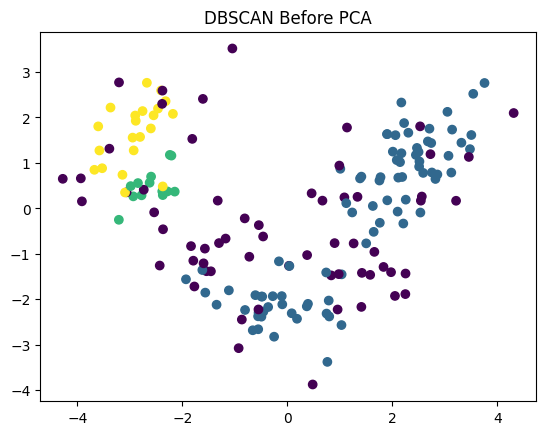

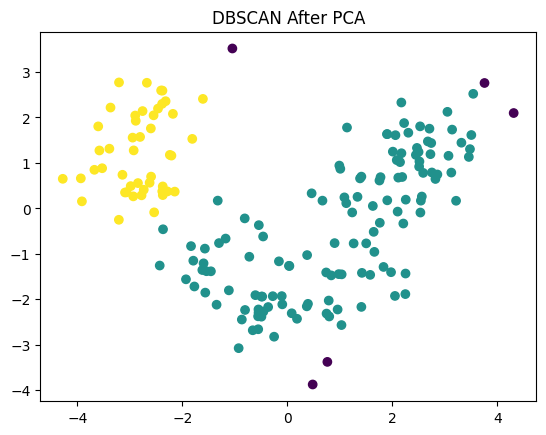

In [36]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# before pca
dbscan_before = DBSCAN(eps=2.1, min_samples=5)
labels_before = dbscan_before.fit_predict(X_scaled)

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_before, cmap='viridis')
plt.title("DBSCAN Before PCA") # but (visualized with PCA)
plt.show()

# after pca
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

dbscan_after = DBSCAN(eps=0.8, min_samples=5)  #tuned eps
labels_after = dbscan_after.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_after, cmap='viridis')
plt.title("DBSCAN After PCA")
plt.show()
